   Temperature  Humidity  Weekend  Sales
0           18        85        0    100
1           20        80        0    120
2           22        75        0    140
3           25        70        1    200
4           28        65        1    250
5           30        60        1    300
6           32        58        1    320
7           35        55        1    350
8           27        68        0    220
9           24        72        0    180
mse  400.0
rmse  20.0
R2score  0.84
Temperature  :  0.12
Humidity  :  0.88
Weekend  :  0.0


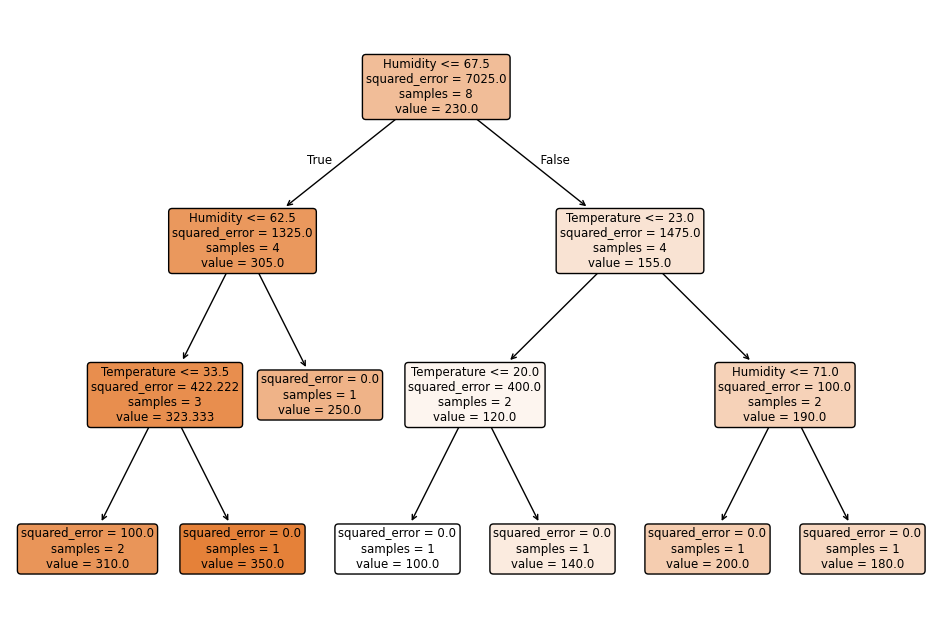

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
import pickle

data = {
            "Temperature":[18,20,22,25,28,30,32,35,27,24],
            "Humidity":[85,80,75,70,65,60,58,55,68,72],
            "Weekend":[0,0,0,1,1,1,1,1,0,0],
            "Sales":[100,120,140,200,250,300,320,350,220,180]
        }
df = pd.DataFrame(data)
print(df)
x = df[['Temperature', 'Humidity', 'Weekend']]
y = df['Sales']
# print(x)
# print(y)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42)
model = DecisionTreeRegressor(max_depth=3, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
# print(y_pred)
mse = mean_squared_error(y_test, y_pred)
print('mse ',mse)
rmse = np.sqrt(mse)
print('rmse ',rmse)
R2score = r2_score(y_test, y_pred)
print('R2score ',R2score)

for feature, score in zip(x.columns, model.feature_importances_):
    print(feature,' : ',round(score,2))

plt.figure(figsize=(12,8))
plot_tree(
        model,
        feature_names = x.columns,
        filled=True,
        rounded=True
)
plt.show()

with open(r"D:\Python-Course\ML-Course\test\Machine-Learning-Algorithm\Decision-Tree-Regression\ice_cream_sales_model.pkl",'wb') as f:
    pickle.dump(model, f)
